# EXPLORATORY DATA ANALYSIS

## Setup

In [59]:
# %matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
sns.set(color_codes=True)

In [75]:
PROJECT_ROOT = Path().resolve().parent
DATA_FOLDER = PROJECT_ROOT / "data" / "processed"

games_df = pd.read_csv(DATA_FOLDER / "games.csv")
users_df = pd.read_csv(DATA_FOLDER / "users.csv")
recommendations_df = pd.read_csv(DATA_FOLDER / "recommendations.csv")
games_df = games_df.drop(columns=['price_final'])

## Verifying data correctness

In [77]:
# games_df.dtypes
games_df.count()
users_df.count()
recommendations_df.dtypes

app_id              int64
helpful             int64
funny               int64
date               object
is_recommended       bool
hours             float64
user_id             int64
review_id           int64
dtype: object

In [80]:
games_df.dtypes

app_id              int64
title              object
date_release       object
win                  bool
mac                  bool
linux                bool
rating             object
positive_ratio      int64
user_reviews        int64
price_original    float64
discount          float64
steam_deck           bool
rating_score      float64
dtype: object

In [81]:
users_df.dtypes

user_id     int64
products    int64
reviews     int64
dtype: object

## Outliers identification

<Axes: xlabel='rating_score'>

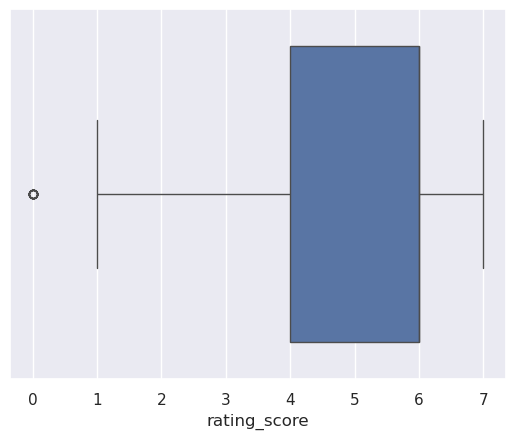

In [ ]:
sns.boxplot(x=games_df.rating_score)

<Axes: xlabel='reviews'>

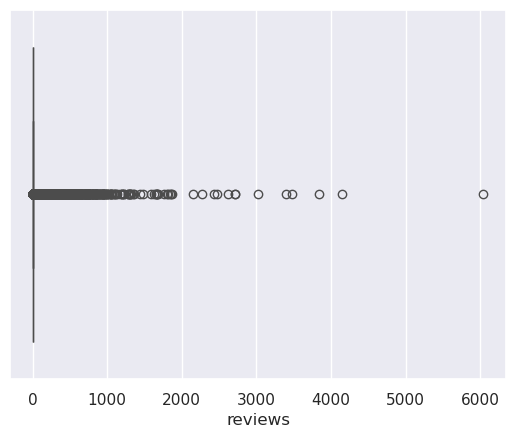

In [ ]:
sns.boxplot(x=users_df.reviews)
# consider users with >= 3000 reviews as outliers and remove them?
# users_df = users_df[users_df['reviews'] < 3000]

<Axes: xlabel='price_original'>

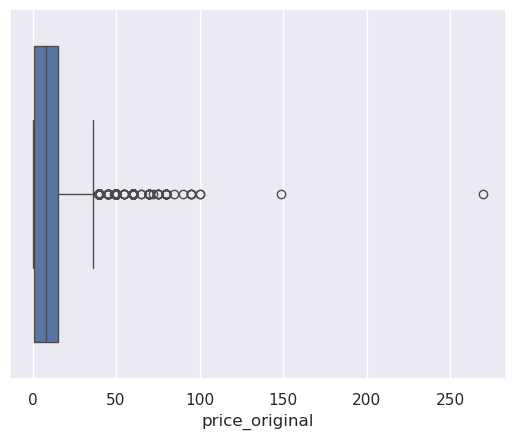

In [ ]:
sns.boxplot(x=games_df.price_original)
# price >= 100 outliers?
# games_df = games_df[games_df['price_original'] < 100]

## Stats

In [73]:
games_df[games_df['price_original'] > 100]

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_original,discount,steam_deck,rating_score
10867,502570,Houdini Indie,2018-10-10,True,True,False,Very Positive,94,148,269.99,0.0,True,6.0
15025,1325400,VEGAS Pro 18 Edit Steam Edition,2020-09-03,True,False,False,Mixed,51,154,149.00,0.0,True,3.0


,hours,is_recommended,funny,helpful
hours,1.000000,0.042806,0.006519,0.008144
is_recommended,0.042806,1.000000,-0.003359,-0.026768
funny,0.006519,-0.003359,1.000000,0.480273
helpful,0.008144,-0.026768,0.480273,1.000000


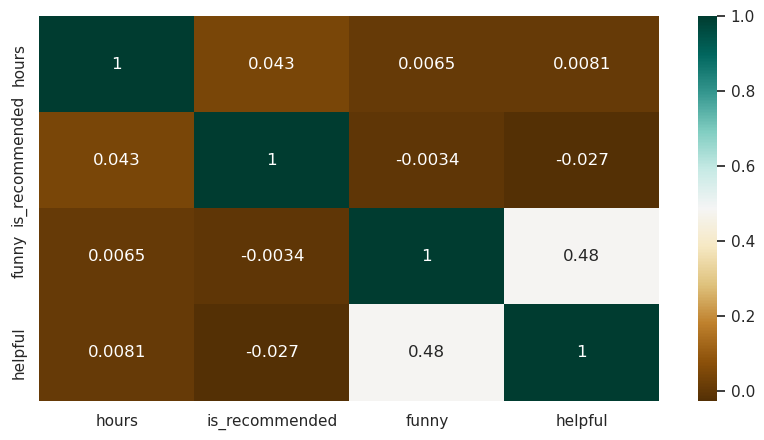

In [79]:
plt.figure(figsize=(10,5))
c= recommendations_df[['hours', 'is_recommended', 'funny', 'helpful']].corr()
sns.heatmap(c,cmap="BrBG",annot=True)
c


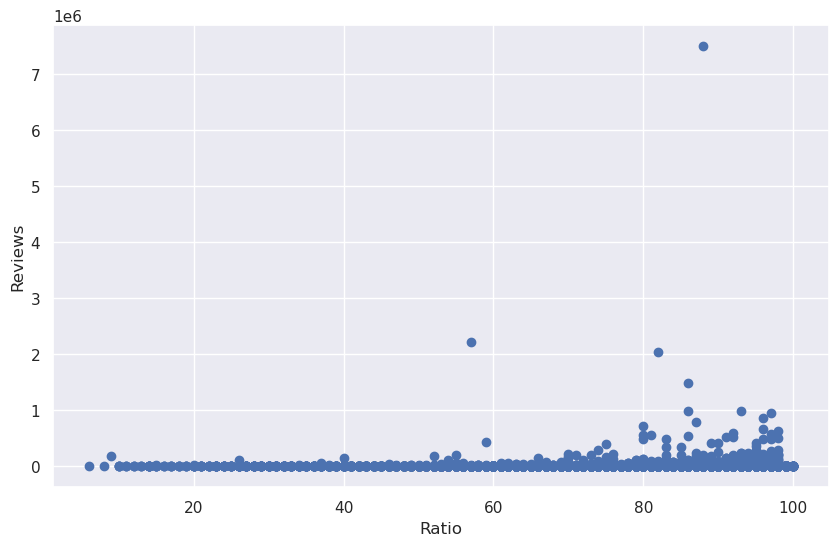

In [85]:
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(games_df['positive_ratio'], games_df['user_reviews'])
ax.set_xlabel('Ratio')
ax.set_ylabel('Reviews')
plt.show()